In [24]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [25]:
import time
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [26]:
# df = pd.read_csv("../data/processed/processed_data.csv")

In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/iamnitishsah/FoodOps.AI/refs/heads/main/DemandOps/data/processed/processed_data.csv")

In [28]:
max_week = df['week'].max()
print(f"Max week: {max_week}")

Max week: 145


In [29]:
val_weeks = int(max_week * 0.10)
print(f"Validation weeks: {val_weeks}")

Validation weeks: 14


In [30]:
cutoff_week = max_week - val_weeks
print(f"Cutoff week: {cutoff_week}")

Cutoff week: 131


In [31]:
train_df = df[df['week'] <= cutoff_week].copy()
val_df   = df[df['week'] > cutoff_week].copy()
print(f"Train: weeks 1-{cutoff_week}  -> {len(train_df):,} rows")
print(f"Val:   weeks {cutoff_week+1}-{max_week} -> {len(val_df):,} rows")

Train: weeks 1-131  -> 471,207 rows
Val:   weeks 132-145 -> 50,358 rows


# MAPE(Mean Absolute Percentage Error)

In [32]:
def mape(y_true, y_pred):
    mask = y_true != 0  # avoid div-by-zero; exclude true zeros from MAPE
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

# WAPE(Weighted Absolute Percentage Error)

In [33]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

# Baseline model: naive lag-1 prediction

In [34]:
val_baseline_pred_log = val_df['lag_1']
val_baseline_pred = np.expm1(val_baseline_pred_log)

# clip negative predictions to 0 — orders can't be negative, and expm1 of a small/negative log value could theoretically dip below 0
val_baseline_pred = np.clip(val_baseline_pred, 0, None)

val_actual = np.expm1(val_df['log_num_orders'])  # ground truth, back on orders scale

In [35]:
print(np.allclose(val_actual, val_df['num_orders']))
print((val_actual - val_df['num_orders']).abs().max())

True
2.546585164964199e-11


In [36]:
baseline_mape = mape(val_actual.values, val_baseline_pred.values)
baseline_wape = wape(val_actual.values, val_baseline_pred.values)

print(f"--- Baseline Naive ---")
print(f"WAPE: {baseline_wape:.2f}% | MAPE: {baseline_mape:.2f}%")

--- Baseline Naive ---
WAPE: 41.96% | MAPE: 67.23%


# Regression model: Ridge Regression

In [37]:
# Define feature columns
calendar_features = ['week_of_year']

numeric_features = [
    'checkout_price', 'base_price', 'price_change_pct',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_std_4',
    'op_area'
] + calendar_features

binary_features = [
    'emailer_for_promotion',
    'homepage_featured'
]

categorical_features = [
    'category', 'cuisine', 'center_type',
    'center_id', 'meal_id'
]

features = numeric_features + binary_features + categorical_features
target = 'log_num_orders'

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]
val_actual = val_df['num_orders'].values

In [38]:
# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
    ]
)

In [39]:
# Create and fit Ridge Pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10))
])

print("Fitting Ridge model...")
ridge_pipeline.fit(X_train, y_train)

Fitting Ridge model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['checkout_price',
                                                   'base_price',
                                                   'price_change_pct', 'lag_1',
                                                   'lag_2', 'lag_4',
                                                   'rolling_mean_4',
                                                   'rolling_std_4', 'op_area',
                                                   'week_of_year']),
                                                 ('bin', 'passthrough',
                                                  ['emailer_for_promotion',
                                                   'homepage_featured']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'cuisine',
                                                   'center_type', 'center_id',
                                                   'meal_id'])])),
                ('regressor', Ridge(alpha=10))])

In [40]:
# Predict on Validation set
ridge_pred_log = ridge_pipeline.predict(X_val)

In [41]:
# Transform back to raw orders scale and clip at 0
ridge_pred = np.expm1(ridge_pred_log)
ridge_pred = np.clip(ridge_pred, 0, None)

In [42]:
# Evaluate
ridge_mape = mape(val_actual, ridge_pred)
ridge_wape = wape(val_actual, ridge_pred)

print(f"--- Baseline Naive ---")
print(f"WAPE: {baseline_wape:.2f}% | MAPE: {baseline_mape:.2f}%")
print(f"\n--- Ridge Regression ---")
print(f"WAPE: {ridge_wape:.2f}% | MAPE: {ridge_mape:.2f}%")

--- Baseline Naive ---
WAPE: 41.96% | MAPE: 67.23%

--- Ridge Regression ---
WAPE: 35.72% | MAPE: 46.98%


# Boosting model: LightGBM

In [43]:
# Define feature lists for LightGBM
calendar_features = ['week_of_year']
cat_cols = ['category', 'cuisine', 'center_type', 'center_id', 'meal_id']
num_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_std_4',
    'op_area'
] + calendar_features

In [44]:
# Prepare X and y, explicitly casting categoricals to 'category' dtype
X_train_lgb = train_df[features].copy()
y_train_lgb = train_df['log_num_orders'].copy()

X_val_lgb   = val_df[features].copy()
y_val_lgb = val_df[target].copy()
val_lgb_actual = val_df['num_orders'].values

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')

In [45]:
# Instantiate LightGBM Regressor directly
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [46]:
# Fit directly on the DataFrames
model_lgb.fit(
    X_train_lgb,
    y_train_lgb,
    # eval_X=X_val_lgb,
    # eval_y=y_val_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=50
        )
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2268
[LightGBM] [Info] Number of data points in the train set: 471207, number of used features: 17
[LightGBM] [Info] Start training from score 4.691348
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.538237


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, num_leaves=63, objective='regression_l1',
              random_state=42, subsample=0.8)

In [47]:
# Predict and invert scale
lgb_pred_log = model_lgb.predict(X_val_lgb)
lgb_pred = np.clip(np.expm1(lgb_pred_log), 0, None)

In [48]:
# Compute Metrics
lgb_wape = wape(val_actual, lgb_pred)
lgb_mape = mape(val_actual, lgb_pred)

In [49]:
print(f"\n================ MODEL COMPARISON ================")
print(f"1. Naive Baseline : WAPE = {baseline_wape:.2f}% | MAPE = {baseline_mape:.2f}%")
print(f"2. Ridge Regressor: WAPE = {ridge_wape:.2f}% | MAPE = {ridge_mape:.2f}%")
print(f"3. LightGBM       : WAPE = {lgb_wape:.2f}% | MAPE = {lgb_mape:.2f}%")
print(f"==================================================")


================ MODEL COMPARISON ================
1. Naive Baseline : WAPE = 41.96% | MAPE = 67.23%
2. Ridge Regressor: WAPE = 35.72% | MAPE = 46.98%
3. LightGBM       : WAPE = 28.75% | MAPE = 44.14%


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

Text(0.5, 1.0, 'Feature Importance by Gain (Loss Reduction)')

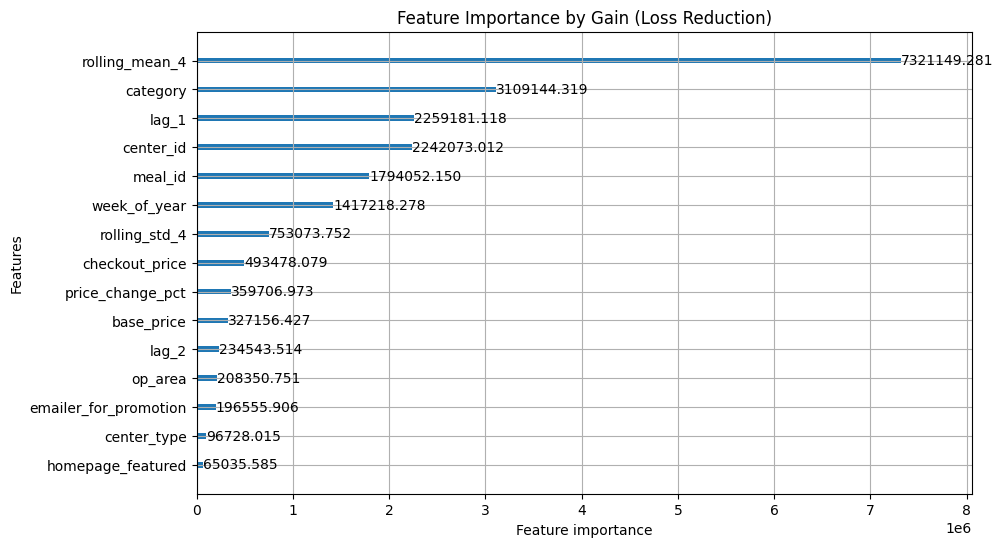

In [50]:
lgb.plot_importance(model_lgb, importance_type='gain', max_num_features=15, figsize=(10, 6))
plt.title("Feature Importance by Gain (Loss Reduction)")
plt.show()

In [51]:
# # Ensure output directory exists
# models_dir = "../models"
# os.makedirs(models_dir, exist_ok=True)

# # Save the standalone scikit-learn compatible LGBMRegressor
# joblib.dump(model_lgb, os.path.join(models_dir, "lgb_model.joblib"))

# # 2. Recommended: Save an artifact bundle containing feature metadata
# lgb_bundle = {
#     "model": model_lgb,
#     "features": features,
#     "cat_cols": cat_cols,
#     "target": "num_orders",
#     "target_transform": "log1p",  # indicates np.expm1() is needed on predictions
#     "metrics": {
#         "val_wape": lgb_wape,
#         "val_mape": lgb_mape
#     }
# }
# bundle_path = os.path.join(models_dir, "lgb_model_bundle.joblib")
# joblib.dump(lgb_bundle, bundle_path)

# print(f"Model and bundle successfully exported to: {os.path.abspath(models_dir)}")

# Neural Network Model: LSTM

In [52]:
# Optimize thread scheduling for M2 P-cores
torch.set_num_threads(4)
device = torch.device('cpu') # CPU is faster than MPS for small LSTMs on Apple Silicon
print(f"Training on device: {device}")

Training on device: cpu


In [53]:
# Trajectory features (what happened over the last 8 weeks)
history_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'week_of_year', 'log_num_orders'
]

# Known future features (what is scheduled for target week t)
target_known_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'week_of_year'
]

# Static continuous entity features
static_num_cols = ['op_area']

In [54]:
# Fit scaler strictly on training weeks (week <= cutoff_week)
train_mask = df['week'] <= cutoff_week
scaler = StandardScaler()
cols_to_scale = list(set(history_cols + target_known_cols + static_num_cols))
scaler.fit(df.loc[train_mask, cols_to_scale])

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.transform(df[cols_to_scale])

# Target scaler: scale the log target so loss and gradients stay normalized
target_mean = float(df.loc[train_mask, 'log_num_orders'].mean())
target_std  = float(df.loc[train_mask, 'log_num_orders'].std())
df_scaled['target_norm'] = ((df['log_num_orders'] - target_mean) / target_std).astype(np.float32)

print("Feature and target scaling complete.")

StandardScaler()

Feature and target scaling complete.


In [55]:
print("Vectorizing data into memory (matching DataFrame index order)...")

seq_len = 8
num_weeks = int(df['week'].max())
num_series = len(df) // num_weeks

hist_arr = df_scaled[history_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(history_cols))
target_known_arr = df_scaled[target_known_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(target_known_cols))
static_num_arr = df_scaled[static_num_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(static_num_cols))[:, 0, :]
targets_arr = df_scaled['target_norm'].to_numpy(dtype=np.float32).reshape(num_series, num_weeks)

X_hist_train, X_known_train, X_stat_train, Y_train = [], [], [], []
X_hist_val, X_known_val, X_stat_val, Y_val = [], [], [], []

for s in range(num_series):
    # Train (skip first `seq_len` weeks so we have full history)
    for t in range(seq_len, cutoff_week):
        X_hist_train.append(hist_arr[s, t - seq_len : t, :])
        X_known_train.append(target_known_arr[s, t, :])
        X_stat_train.append(static_num_arr[s, :])
        Y_train.append(targets_arr[s, t])

    # Validation
    for t in range(cutoff_week, num_weeks):
        X_hist_val.append(hist_arr[s, t - seq_len : t, :])
        X_known_val.append(target_known_arr[s, t, :])
        X_stat_val.append(static_num_arr[s, :])
        Y_val.append(targets_arr[s, t])

# Convert to contiguous PyTorch tensors
t_X_hist_train = torch.tensor(np.stack(X_hist_train))
t_X_known_train = torch.tensor(np.stack(X_known_train))
t_X_stat_train = torch.tensor(np.stack(X_stat_train))
t_Y_train = torch.tensor(np.array(Y_train, dtype=np.float32))

t_X_hist_val = torch.tensor(np.stack(X_hist_val))
t_X_known_val = torch.tensor(np.stack(X_known_val))
t_X_stat_val = torch.tensor(np.stack(X_stat_val))
t_Y_val = torch.tensor(np.array(Y_val, dtype=np.float32))

print(f"Train tensor shape: {t_X_hist_train.shape} | Val tensor shape: {t_X_hist_val.shape}")

Vectorizing data into memory (matching DataFrame index order)...
Train tensor shape: torch.Size([442431, 8, 7]) | Val tensor shape: torch.Size([50358, 8, 7])


In [56]:
class SimpleDemandLSTM(nn.Module):
    def __init__(self, history_dim, target_known_dim, num_static_cont, hidden_dim=32, num_layers=1):
        super().__init__()

        # 1. Standard LSTM for the 8-week historical sequence
        self.lstm = nn.LSTM(
            input_size=history_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 2. Linear layer combining the LSTM summary with current-week features
        combined_dim = hidden_dim + target_known_dim + num_static_cont
        self.fc = nn.Linear(combined_dim, 1)

    def forward(self, x_hist, x_target_known, x_stat_num):
        # Process history through LSTM
        lstm_out, (h_n, c_n) = self.lstm(x_hist)
        last_hidden = h_n[-1]

        # Concatenate outputs and predict
        fusion = torch.cat([last_hidden, x_stat_num, x_target_known], dim=1)
        out = self.fc(fusion)
        return out.squeeze(-1)

In [57]:
# Initialize the simple model
model = SimpleDemandLSTM(
    history_dim=len(history_cols),
    target_known_dim=len(target_known_cols),
    num_static_cont=len(static_num_cols),
    hidden_dim=32,
    num_layers=1
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

batch_size = 2048  # Large batch size for CPU vectorization speedup
n_train = t_X_hist_train.shape[0]
n_val = t_X_hist_val.shape[0]
epochs = 10

best_wape = float("inf")
best_mape = float("inf")

# Ensure val_actual exactly matches original dataframe
val_actual = val_df['num_orders'].values

print("Starting Fast M2 Training Loop...\n")

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    model.train()

    # Shuffle indices per epoch
    perm = torch.randperm(n_train)
    total_train_loss = 0.0

    # --- TRAINING PHASE ---
    for i in range(0, n_train, batch_size):
        idx = perm[i : i + batch_size]

        # Direct tensor slicing (fast)
        b_hist = t_X_hist_train[idx].to(device)
        b_known = t_X_known_train[idx].to(device)
        b_stat = t_X_stat_train[idx].to(device)
        b_y = t_Y_train[idx].to(device)

        optimizer.zero_grad(set_to_none=True)
        preds = model(b_hist, b_known, b_stat)
        loss = criterion(preds, b_y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(b_y)

    avg_train_loss = total_train_loss / n_train

    # --- VALIDATION PHASE ---
    model.eval()
    val_preds = []
    total_val_loss = 0.0

    with torch.no_grad():
        for i in range(0, n_val, batch_size * 2):
            b_hist = t_X_hist_val[i : i + batch_size * 2].to(device)
            b_known = t_X_known_val[i : i + batch_size * 2].to(device)
            b_stat = t_X_stat_val[i : i + batch_size * 2].to(device)
            b_y = t_Y_val[i : i + batch_size * 2].to(device)

            p = model(b_hist, b_known, b_stat)
            loss = criterion(p, b_y)
            total_val_loss += loss.item() * len(b_y)
            val_preds.append(p.cpu().numpy())

    avg_val_loss = total_val_loss / n_val
    val_preds_norm = np.concatenate(val_preds, axis=0)

    # Un-scale predictions
    preds_log = val_preds_norm * target_std + target_mean
    raw_preds = np.clip(np.expm1(preds_log), 0, None)

    # Compute business metrics
    current_wape = wape(val_actual, raw_preds)
    current_mape = mape(val_actual, raw_preds)

    is_best = current_wape < best_wape
    if is_best:
        best_wape = current_wape
        best_mape = current_mape

    elapsed = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{epochs:02d} ({elapsed:.1f}s) | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
        f"Val WAPE: {current_wape:.2f}% | Val MAPE: {current_mape:.2f}%"
        + (" [★ Best]" if is_best else "")
    )

print(f"\nFinal Best Simple LSTM Validation WAPE: {best_wape:.2f}%")

Starting Fast M2 Training Loop...



SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

Epoch 01/10 (13.4s) | Train Loss: 0.1349 | Val Loss: 0.0960 | Val WAPE: 31.84% | Val MAPE: 45.87% [★ Best]


SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

...

SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

Epoch 09/10 (13.2s) | Train Loss: 0.0929 | Val Loss: 0.0921 | Val WAPE: 30.28% | Val MAPE: 43.30%


SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

SimpleDemandLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=39, out_features=1, bias=True)
)

Epoch 10/10 (13.1s) | Train Loss: 0.0926 | Val Loss: 0.0921 | Val WAPE: 30.14% | Val MAPE: 43.54%

Final Best Simple LSTM Validation WAPE: 29.98%


In [58]:
print(f"\n================ MODEL COMPARISON ================")
print(f"1. Naive Baseline : WAPE = {baseline_wape:.2f}% | MAPE = {baseline_mape:.2f}%")
print(f"2. Ridge Regressor: WAPE = {ridge_wape:.2f}% | MAPE = {ridge_mape:.2f}%")
print(f"3. LightGBM       : WAPE = {lgb_wape:.2f}% | MAPE = {lgb_mape:.2f}%")
print(f"4. Simple LSTM    : WAPE = {best_wape:.2f}% | MAPE = {best_mape:.2f}%")
print(f"==================================================")


================ MODEL COMPARISON ================
1. Naive Baseline : WAPE = 41.96% | MAPE = 67.23%
2. Ridge Regressor: WAPE = 35.72% | MAPE = 46.98%
3. LightGBM       : WAPE = 28.75% | MAPE = 44.14%
4. Simple LSTM    : WAPE = 29.98% | MAPE = 44.02%
